# Paired A/B Model Comparison via Pólya–Gamma Gibbs Sampling

This notebook implements **exact** Bayesian logistic regression for paired binary scores
using the **Pólya–Gamma data-augmentation** scheme (Polson, Scott & Windle, 2013).

## Why Pólya–Gamma?

The Laplace notebook approximates the posterior as a Gaussian around the MAP.
PG augmentation gives us **exact** posterior samples via a simple Gibbs sampler —
no optimisation, no Gaussian approximation, no MCMC tuning.

### Key idea

The Bernoulli log-likelihood with a logistic link can be written as:

$$
p(y \mid \beta) = \prod_i \frac{(e^{\psi_i})^{y_i}}{1 + e^{\psi_i}}
= \prod_i \frac{e^{\kappa_i \psi_i}}{\cosh(\psi_i / 2)} \cdot 2^{-n}
$$

where $\psi_i = x_i^\top \beta$ and $\kappa_i = y_i - \tfrac{1}{2}$.

Introducing latent $\omega_i \sim \mathrm{PG}(1, 0)$, we get a **conditionally Gaussian** likelihood:

$$
p(y \mid \beta, \omega) \propto \exp\!\left(-\tfrac{1}{2} (\beta^\top X^\top \Omega X \beta - 2 \kappa^\top X \beta)\right)
$$

Combined with a Gaussian prior $\beta \sim N(b_0, B_0)$, the full conditional for $\beta$ is:

$$
\beta \mid \omega, y \sim N(\mu_\beta,\, \Sigma_\beta)
$$
$$
\Sigma_\beta = (X^\top \Omega X + B_0^{-1})^{-1}, \quad
\mu_\beta = \Sigma_\beta (X^\top \kappa + B_0^{-1} b_0)
$$

And the full conditional for $\omega$:

$$
\omega_i \mid \beta \sim \mathrm{PG}(1,\, x_i^\top \beta)
$$

The Gibbs sampler alternates between these two closed-form steps.

## Design matrix for paired A/B comparison

We stack both arms into a single regression:

| Observation | Intercept | $d_A$ |
|---|---|---|
| $y_{A,i}$ | 1 | 1 |
| $y_{B,i}$ | 1 | 0 |

So $\beta = (\mu,\, \delta_A)^\top$ with:
- $p_A = \sigma(\mu + \delta_A)$
- $p_B = \sigma(\mu)$

This is the **same** pooled Bernoulli logistic model as the Laplace notebook,
but now fitted with exact MCMC instead of a Gaussian approximation.

## Sanity check on simulated data

### (Optional) Load real evaluation scores instead of simulated data

To use real scores from `eval_scores.json` (created by `eval_dataset_creation.ipynb`),
run the cell below **instead of** the simulated data cell that follows.
Then set `y_A_sim = y_A` and `y_B_sim = y_B` so the rest of the notebook works unchanged.

In [1]:
# # ── Uncomment to use real scores instead of simulated data ────────────
# from bayesAB.config import global_config as glob
# from bayesAB.services.file import JSONService
#
# scores_svc = JSONService(path="eval_scores.json", root_path=glob.DATA_PKG_DIR, verbose=True)
# cached = scores_svc.doRead()
#
# METRIC = "Faithfulness"  # or "Answer Relevancy"
# BINARIZE_THRESHOLD = 0.7
#
# m = cached['metrics'][METRIC]
# s_A = np.array(m['s_A_raw'])
# s_B = np.array(m['s_B_raw'])
# n = min(len(s_A), len(s_B))
#
# y_A_sim = (s_A[:n] >= BINARIZE_THRESHOLD).astype(float)
# y_B_sim = (s_B[:n] >= BINARIZE_THRESHOLD).astype(float)
#
# print(f"Loaded {METRIC} scores from eval_scores.json")
# print(f"  n={n}, A pass rate={y_A_sim.mean():.1%}, B pass rate={y_B_sim.mean():.1%}")

In [2]:
import numpy as np
from bayesAB.resources.bayes_paired_pg import PairedBayesPropTestPG, sigmoid
from bayesAB.resources.bayes_paired_laplace import PairedBayesPropTest, _format_bf
from bayesAB.utils.utils import simulate_paired_scores

# Simulate paired binary data (same DGP as Laplace notebook)
sim = simulate_paired_scores(N=200, delta_A=0.5, sigma_theta=0.0, seed=42)
y_A_sim = sim["y_A"]
y_B_sim = sim["y_B"]

print(f"True δ_A = {sim['true_params']['delta_A']}")
print(f"Fraction y=1:  A={y_A_sim.mean():.1%},  B={y_B_sim.mean():.1%}")

True δ_A = 0.5
Fraction y=1:  A=62.5%,  B=51.5%


In [3]:
# Fit PG model using PairedBayesPropTestPG class
pg_model = PairedBayesPropTestPG(
    seed=42, n_iter=2000, burn_in=500, n_chains=4
).fit(y_A_sim, y_B_sim)

s = pg_model.summary
print(f"δ_A posterior mean = {s.delta_A_posterior_mean:+.4f}")
print(f"Mean Δ (prob)  = {s.mean_delta:+.4f}")
print(f"95% CI         = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A>B)         = {s.p_A_greater_B:.4f}")

bf_pg = pg_model.savage_dickey_test()
print(f"\nBF₁₀ = {bf_pg.BF_10:.2f}  → {bf_pg.decision}")

delta_samples = pg_model.delta_A_samples
mu_samples = pg_model.samples[:, 0]

display(pg_model.trace_summary)

δ_A posterior mean = +0.4373
Mean Δ (prob)  = +0.1062
95% CI         = [0.0112, 0.1971]
P(A>B)         = 0.9850

BF₁₀ = 2.12  → Fail to reject H0


,mean,sd,hdi_3%,hdi_97%,R-hat,ESS
delta_A,0.437323,0.197669,0.063410,0.805133,0.999786,5677.703045
mu,0.067490,0.140314,-0.193076,0.327766,0.999877,5672.602294


## Compare PG vs Laplace posteriors

In [5]:
# Fit the same data with the Laplace model for comparison
laplace_model = PairedBayesPropTest(seed=42, n_samples=2000).fit(y_A_sim, y_B_sim)

laplace_delta = laplace_model.delta_A_samples
laplace_mu = laplace_model.laplace["mu_samples"]

print("PG Gibbs vs Laplace — posterior summary")
print("=" * 55)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 55)
print(f"{'δ_A mean':20} {delta_samples.mean():>15.4f} {laplace_delta.mean():>15.4f}")
print(f"{'δ_A sd':20} {delta_samples.std():>15.4f} {laplace_delta.std():>15.4f}")
print(f"{'μ mean':20} {mu_samples.mean():>15.4f} {laplace_mu.mean():>15.4f}")
print("=" * 55)

PG Gibbs vs Laplace — posterior summary
                            PG Gibbs         Laplace
-------------------------------------------------------
δ_A mean                      0.4373          0.4272
δ_A sd                        0.1977          0.1996
μ mean                        0.0675          0.0709


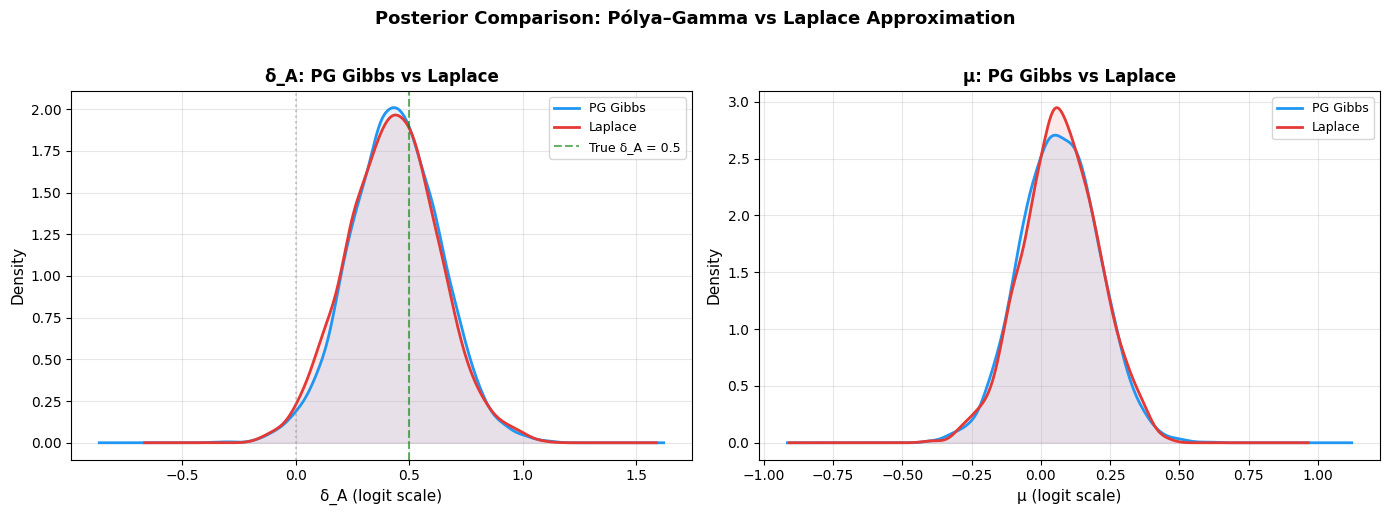

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# δ_A comparison
ax = axes[0]
for samples, label, color in [
    (delta_samples, "PG Gibbs", "#2196F3"),
    (laplace_delta, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.axvline(0.5, color="green", ls="--", alpha=0.6, label="True δ_A = 0.5")
ax.axvline(0, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("δ_A: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# μ comparison
ax = axes[1]
for samples, label, color in [
    (mu_samples, "PG Gibbs", "#2196F3"),
    (laplace_mu, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.set_xlabel("μ (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("μ: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle("Posterior Comparison: Pólya–Gamma vs Laplace Approximation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## MCMC diagnostics

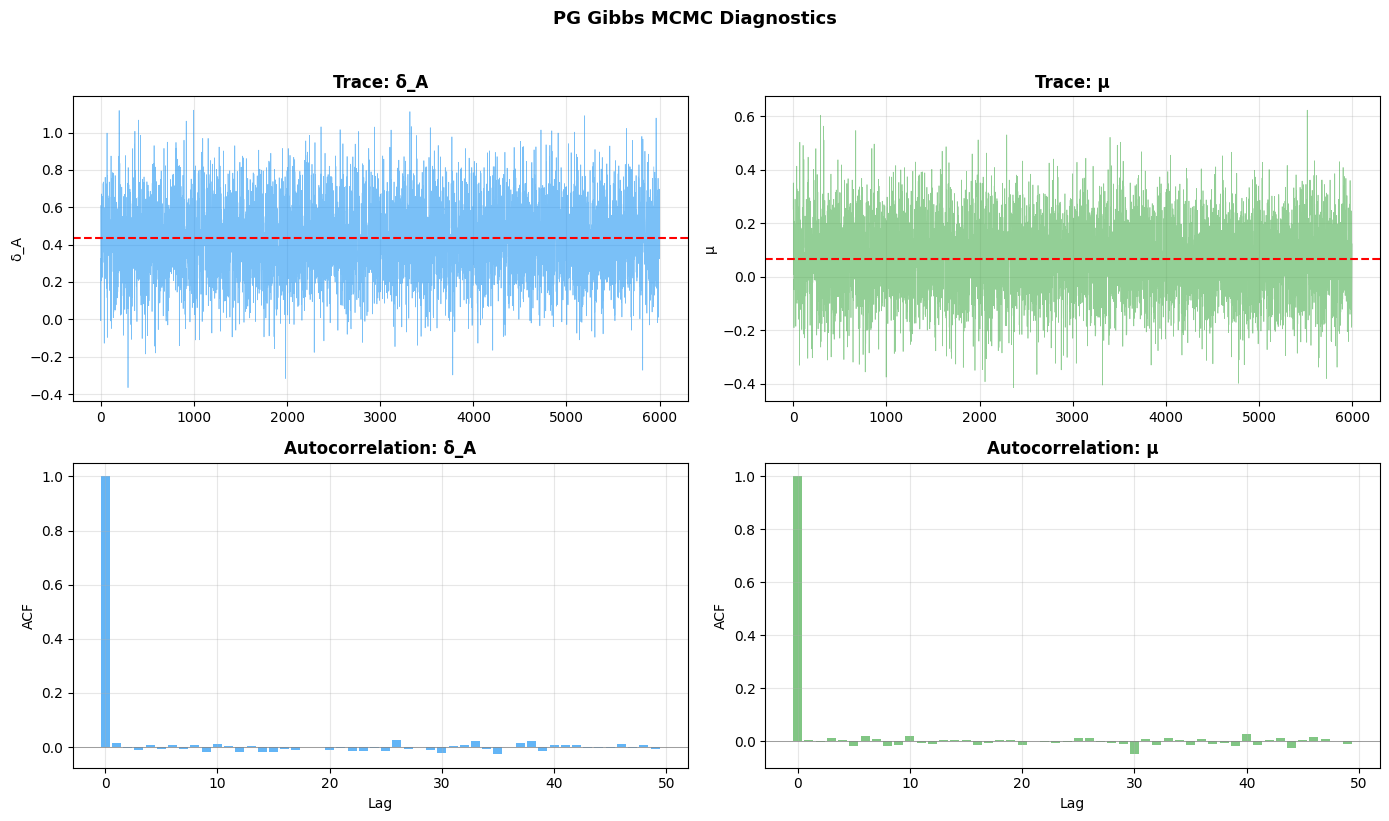

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Trace plots
axes[0, 0].plot(delta_samples, alpha=0.6, linewidth=0.5, color="#2196F3")
axes[0, 0].axhline(delta_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 0].set_ylabel("δ_A")
axes[0, 0].set_title("Trace: δ_A", fontweight="bold")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(mu_samples, alpha=0.6, linewidth=0.5, color="#4CAF50")
axes[0, 1].axhline(mu_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 1].set_ylabel("μ")
axes[0, 1].set_title("Trace: μ", fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# Autocorrelation
max_lag = 50
for ax, samples, name, color in [
    (axes[1, 0], delta_samples, "δ_A", "#2196F3"),
    (axes[1, 1], mu_samples, "μ", "#4CAF50"),
]:
    centered = samples - samples.mean()
    acf = np.correlate(centered, centered, mode="full")
    acf = acf[len(acf) // 2:]
    acf /= acf[0]
    ax.bar(range(max_lag), acf[:max_lag], color=color, alpha=0.7)
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_title(f"Autocorrelation: {name}", fontweight="bold")
    ax.grid(alpha=0.3)

fig.suptitle("PG Gibbs MCMC Diagnostics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Savage-Dickey Bayes Factor

We can compute the same Savage-Dickey test using the PG posterior samples:

$$
BF_{01} = \frac{p(\delta_A = 0 \mid D)}{g(0)}
$$

In [8]:
from scipy.stats import norm

# Use the class method for Savage-Dickey (already computed above as bf_pg)
bf_laplace = laplace_model.savage_dickey_test()

print("Savage-Dickey Bayes Factor comparison")
print("=" * 55)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 55)
print(f"{'Post. density at 0':20} {bf_pg.posterior_density_at_0:>15.4e} {bf_laplace.posterior_density_at_0:>15.4e}")
print(f"{'Prior density at 0':20} {bf_pg.prior_density_at_0:>15.6f} {bf_laplace.prior_density_at_0:>15.6f}")
print(f"{'BF_10':20} {bf_pg.BF_10:>15.2f} {bf_laplace.BF_10:>15.2f}")
print(f"{'log₁₀(BF_10)':20} {np.log10(bf_pg.BF_10):>15.1f} {np.log10(bf_laplace.BF_10):>15.1f}")
print(f"{'Decision':20} {bf_pg.decision:>15} {bf_laplace.decision:>15}")
print("=" * 55)

Savage-Dickey Bayes Factor comparison
                            PG Gibbs         Laplace
-------------------------------------------------------
Post. density at 0        1.8795e-01      2.2843e-01
Prior density at 0          0.398942        0.398942
BF_10                           2.12            1.75
log₁₀(BF_10)                     0.3             0.2
Decision             Fail to reject H0 Fail to reject H0


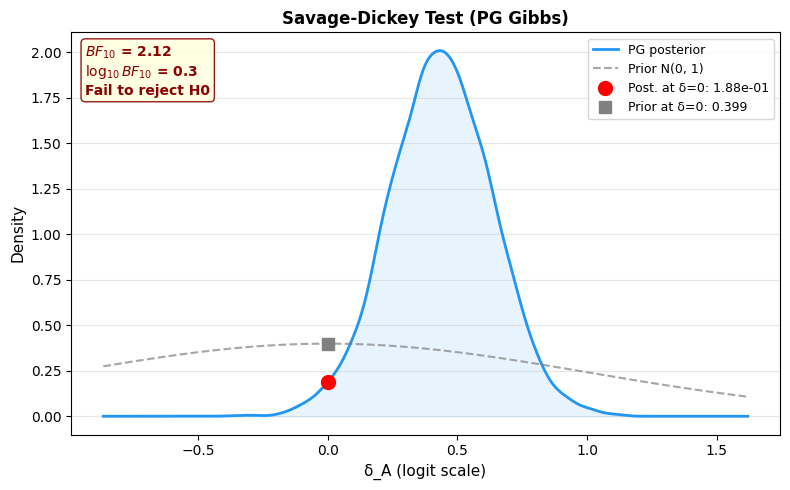

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

kde_pg = gaussian_kde(delta_samples)
x_grid = np.linspace(delta_samples.min() - 0.5, delta_samples.max() + 0.5, 500)

ax.plot(x_grid, kde_pg(x_grid), color="#2196F3", lw=2, label="PG posterior")
ax.fill_between(x_grid, kde_pg(x_grid), alpha=0.1, color="#2196F3")

prior_density = norm.pdf(x_grid, 0, 1.0)
ax.plot(x_grid, prior_density, color="gray", lw=1.5, ls="--", alpha=0.7,
        label="Prior N(0, 1)")

ax.plot(0, bf_pg.posterior_density_at_0, "o", color="red", ms=10, zorder=5,
        label=f"Post. at δ=0: {bf_pg.posterior_density_at_0:.2e}")
ax.plot(0, bf_pg.prior_density_at_0, "s", color="gray", ms=8, zorder=5,
        label=f"Prior at δ=0: {bf_pg.prior_density_at_0:.3f}")

bf10_label = _format_bf(bf_pg.BF_10)
log10_bf = np.log10(bf_pg.BF_10)
ax.text(
    0.02, 0.97,
    f"$BF_{{10}}$ = {bf10_label}\n$\\log_{{10}}BF_{{10}}$ = {log10_bf:.1f}\n{bf_pg.decision}",
    fontsize=10, fontweight="bold", color="darkred",
    transform=ax.transAxes, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
              edgecolor="darkred", alpha=0.9),
)

ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Savage-Dickey Test (PG Gibbs)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Posterior predictive check

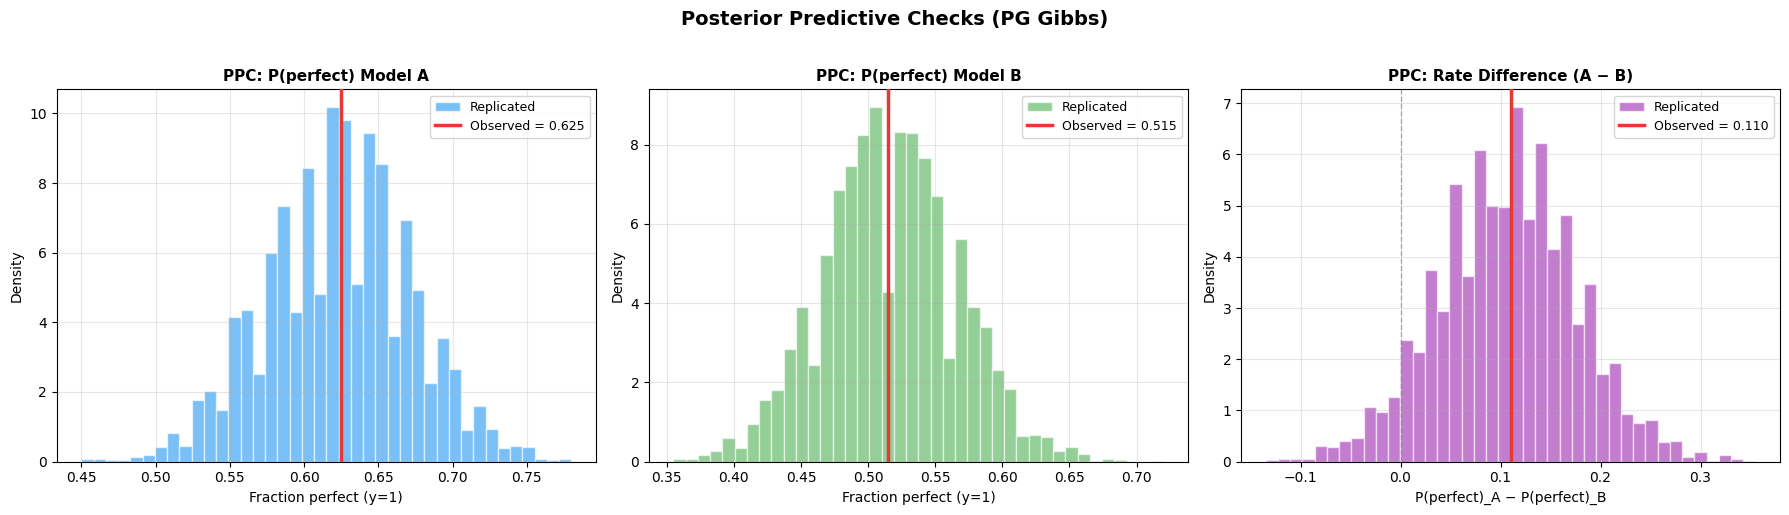

Posterior Predictive p-values (two-sided) — PG Gibbs
Statistic              Observed    p-value     Status
----------------------------------------------------------------------
mean(y_A)                0.6250      1.000         OK
mean(y_B)                0.5150      1.000         OK
mean(y_A-y_B)            0.1100      0.994         OK
std(y_A-y_B)             0.7197      0.285         OK
n_disagree             106.0000      0.378         OK


In [10]:
# ── PPC plots (using class method) ────────────────────────────────────
pg_model.plot_ppc(seed=42)
plt.show()

# ── PPC p-values ─────────────────────────────────────────────────────
print("Posterior Predictive p-values (two-sided) — PG Gibbs")
print("=" * 70)
print(f"{'Statistic':<20} {'Observed':>10} {'p-value':>10} {'Status':>10}")
print("-" * 70)

ppc = pg_model.ppc_pvalues(seed=42)
for stat_name, vals in ppc.items():
    print(f"{stat_name:<20} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>10}")

print("=" * 70)

## Summary comparison: PG Gibbs vs Laplace

| Quantity | PG Gibbs | Laplace |
|---|---|---|
| **Posterior type** | Exact MCMC samples | Gaussian approximation at MAP |
| **Tuning** | None (closed-form conditionals) | L-BFGS-B optimisation |
| **Asymptotic correctness** | Exact for any $n$ | Exact as $n \to \infty$ |
| **Speed** | $O(n \cdot p^2 \cdot T)$ per chain | $O(p^3)$ one-shot |
| **When to prefer** | Small $n$, multimodal posteriors | Large $n$, fast iteration |

## Bayes Factor Design Analysis (BFDA) — Sample Size Planning (Paired PG)

For a hypothesised true effect $\Delta = \theta_A - \theta_B$, we simulate many paired
datasets at each sample size and estimate the probability of obtaining *decisive*
evidence via the PG Gibbs + Savage-Dickey framework:

$$
\text{Bayesian Power}(n) = P\!\left(BF_{10} > \text{threshold} \;\middle|\; \theta_A, \theta_B, n\right)
$$

Since each simulation requires MCMC, the paired BFDA is more expensive than the
non-paired (exact conjugate) version. Use `n_sim=200` for exploration and increase
for final reporting.

### References

1. **Schönbrodt, F. D. & Wagenmakers, E.-J.** (2018). Bayes factor design analysis: Planning for compelling evidence. *Psychonomic Bulletin & Review*, 25(1), 128–142.
2. **Stefan, A. M., Gronau, Q. F., Schönbrodt, F. D., & Wagenmakers, E.-J.** (2019). A tutorial on Bayes Factor Design Analysis using an informed prior. *Behavior Research Methods*, 51(3), 1042–1058.

In [11]:
from bayesAB.utils.utils import (
    bfda_power_curve_paired,
    bfda_power_curve_ph0,
    find_n_for_power,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use the simulated data rates as plug-in estimates ─────────────────
theta_A_hat = y_A_sim.mean()
theta_B_hat = y_B_sim.mean()

print(f"Assumed true rates (from simulated data):")
print(f"  θ_A = {theta_A_hat:.3f}")
print(f"  θ_B = {theta_B_hat:.3f}")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve (paired PG model) ───────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve_paired = bfda_power_curve_paired(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    bf_threshold=3.0,
    n_sim=200,
    n_iter=1000,
    burn_in=300,
    n_chains=2,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve_paired.items():
    print(f"{n:<15} {p:>12.3f}")

n_80 = find_n_for_power(power_curve_paired, 0.80)
print(f"\n→ Estimated n for 80% power: ≈ {n_80:.0f}" if n_80 else "\n→ n for 80% power: > 500")

Assumed true rates (from simulated data):
  θ_A = 0.625
  θ_B = 0.515
  True Δ = 0.110 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.060
30                     0.095
50                     0.125
75                     0.185
100                    0.215
150                    0.280
200                    0.425
300                    0.575
500                    0.820

→ Estimated n for 80% power: ≈ 484


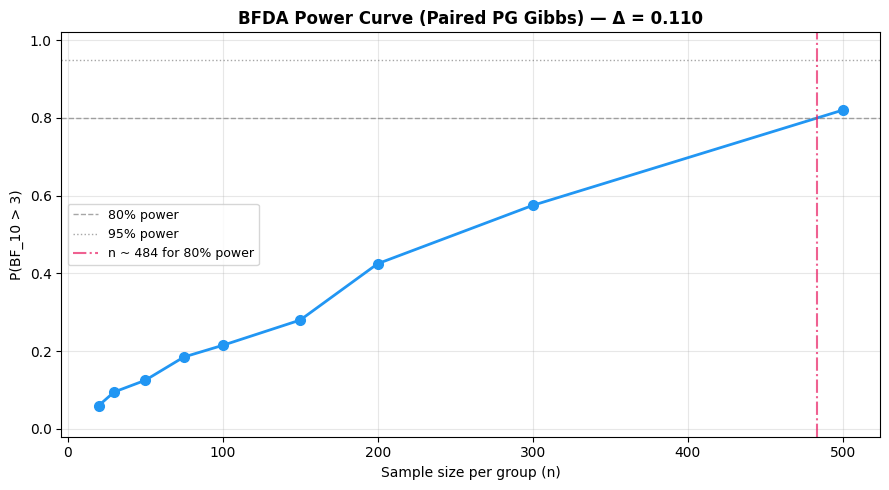

In [12]:
plot_bfda_power(
    power_curve_paired, theta_A_hat, theta_B_hat,
    title=f"BFDA Power Curve (Paired PG Gibbs) — Δ = {theta_A_hat - theta_B_hat:.3f}"
)
plt.show()

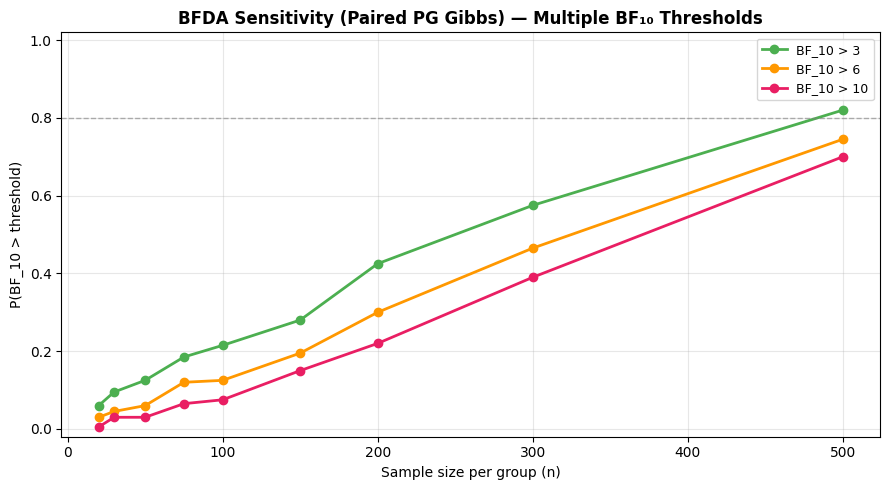

In [13]:
plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=200,
    seed=42,
    design="paired",
    title="BFDA Sensitivity (Paired PG Gibbs) — Multiple BF₁₀ Thresholds",
)
plt.show()